**CUSTOMER CHURN PREDICTION ANALYSIS**

# Customer Churn Prediction — Telco Dataset
**Author:** **IMRAN FAYAZ SHEIKH** | **Date:** **27-04-2026** | **Dataset:** **IBM Telco (Kaggle)**

## Objective
Predict which customers are likely to churn using classification models.

Identify key drivers via SHAP, and quantify the business ROI of intervention

In [46]:
!pip install shap imbalanced-learn xgboost lightgbm -q

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import shap

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [64]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = "plotly_white"

**LOAD DATASET AND FIRST LOOK**

In [65]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", 
                 encoding='utf-8', 
                 on_bad_lines='skip')

In [68]:
data

,SR.NO,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1.0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN,NaN,NaN
1,2.0,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,NaN,NaN,912233.2
2,3.0,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,NaN,NaN,16056168.7
3,4.0,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,NaN,NaN,NaN
4,5.0,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
data.head(7)

,SR.NO,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1.0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN,NaN,NaN
1,2.0,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,NaN,NaN,912233.2
2,3.0,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,NaN,NaN,16056168.7
3,4.0,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,NaN,NaN,NaN
4,5.0,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,NaN,NaN,NaN
5,6.0,9305-CDSKC,Female,0.0,No,No,8.0,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,NaN,NaN,NaN
6,7.0,1452-KIOVK,Male,0.0,No,Yes,22.0,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,NaN,NaN,NaN


In [54]:
data.describe()

,SR.NO,SeniorCitizen,tenure,MonthlyCharges,Unnamed: 22,Unnamed: 23,Unnamed: 24
count,7043.000000,7043.000000,7043.000000,7044.000000,0.0,0.0,2.000000e+00
mean,3522.000000,0.162147,32.371149,129.504997,NaN,NaN,8.484201e+06
std,2033.283305,0.368612,24.559481,5433.894405,NaN,NaN,1.070838e+07
min,1.000000,0.000000,0.000000,18.250000,NaN,NaN,9.122332e+05
25%,1761.500000,0.000000,9.000000,35.500000,NaN,NaN,4.698217e+06
50%,3522.000000,0.000000,29.000000,70.350000,NaN,NaN,8.484201e+06
75%,5282.500000,0.000000,55.000000,89.850000,NaN,NaN,1.227018e+07
max,7043.000000,1.000000,72.000000,456116.600000,NaN,NaN,1.605617e+07


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SR.NO             7043 non-null   float64
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   float64
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   float64
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   ob

In [56]:
data.shape


(1048575, 25)

In [57]:
print(f"Shape: {data.shape}")

Shape: (1048575, 25)


In [58]:
f"Churn rate: {data['Churn'].value_counts(normalize=True)['Yes']:.1%}"  # this will calculate the churn rate in the given data

'Churn rate: 26.5%'

# So the churn rate is 26.5%

In [59]:
data.head()

,SR.NO,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1.0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN,NaN,NaN
1,2.0,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,NaN,NaN,912233.2
2,3.0,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,NaN,NaN,16056168.7
3,4.0,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,NaN,NaN,NaN
4,5.0,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,NaN,NaN,NaN


In [60]:
data.dtypes.value_counts()

object     18
float64     7
Name: count, dtype: int64

In [61]:
data.count()

SR.NO               7043
customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7044
TotalCharges        7043
Churn               7043
Unnamed: 22            0
Unnamed: 23            0
Unnamed: 24            2
dtype: int64

In [62]:
data.isnull().sum()[data.isnull().sum() > 0]

SR.NO               1041532
customerID          1041532
gender              1041532
SeniorCitizen       1041532
Partner             1041532
Dependents          1041532
tenure              1041532
PhoneService        1041532
MultipleLines       1041532
InternetService     1041532
OnlineSecurity      1041532
OnlineBackup        1041532
DeviceProtection    1041532
TechSupport         1041532
StreamingTV         1041532
StreamingMovies     1041532
Contract            1041532
PaperlessBilling    1041532
PaymentMethod       1041532
MonthlyCharges      1041531
TotalCharges        1041532
Churn               1041532
Unnamed: 22         1048575
Unnamed: 23         1048575
Unnamed: 24         1048573
dtype: int64

In [16]:
data.isnull()

,SR.NO,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1048571,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1048572,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1048573,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [17]:
data.isnull().sum()[data.isnull().sum() > 0]

SR.NO               1041532
customerID          1041532
gender              1041532
SeniorCitizen       1041532
Partner             1041532
Dependents          1041532
tenure              1041532
PhoneService        1041532
MultipleLines       1041532
InternetService     1041532
OnlineSecurity      1041532
OnlineBackup        1041532
DeviceProtection    1041532
TechSupport         1041532
StreamingTV         1041532
StreamingMovies     1041532
Contract            1041532
PaperlessBilling    1041532
PaymentMethod       1041532
MonthlyCharges      1041531
TotalCharges        1041532
Churn               1041532
Unnamed: 22         1048575
Unnamed: 23         1048575
Unnamed: 24         1048573
dtype: int64

In [18]:
data= data.dropna(axis=1, how='all')
data = data.dropna(axis=0, how='all')
data.head

<bound method NDFrame.head of           SR.NO  customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0           1.0  7590-VHVEG  Female            0.0     Yes         No     1.0   
1           2.0  5575-GNVDE    Male            0.0      No         No    34.0   
2           3.0  3668-QPYBK    Male            0.0      No         No     2.0   
3           4.0  7795-CFOCW    Male            0.0      No         No    45.0   
4           5.0  9237-HQITU  Female            0.0      No         No     2.0   
...         ...         ...     ...            ...     ...        ...     ...   
7039     7040.0  2234-XADUH  Female            0.0     Yes        Yes    72.0   
7040     7041.0  4801-JZAZL  Female            0.0     Yes        Yes    11.0   
7041     7042.0  8361-LTMKD    Male            1.0     Yes         No     4.0   
7042     7043.0  3186-AJIEK    Male            0.0      No         No    66.0   
1048574     NaN         NaN     NaN            NaN     NaN        NaN     NaN  

In [19]:
data.isnull().sum()[data.isnull().sum() > 0]

SR.NO                  1
customerID             1
gender                 1
SeniorCitizen          1
Partner                1
Dependents             1
tenure                 1
PhoneService           1
MultipleLines          1
InternetService        1
OnlineSecurity         1
OnlineBackup           1
DeviceProtection       1
TechSupport            1
StreamingTV            1
StreamingMovies        1
Contract               1
PaperlessBilling       1
PaymentMethod          1
TotalCharges           1
Churn                  1
Unnamed: 24         7042
dtype: int64

In [20]:
data = data.dropna(axis=1, how='all')
data.drop(columns=[col for col in data.columns if 'Unnamed' in col], inplace=True)

In [21]:
data

,SR.NO,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1.0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,2.0,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3.0,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,4.0,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,5.0,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7039,7040.0,2234-XADUH,Female,0.0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,7041.0,4801-JZAZL,Female,0.0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,7042.0,8361-LTMKD,Male,1.0,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,7043.0,3186-AJIEK,Male,0.0,No,No,66.0,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [22]:
data.shape

(7044, 22)

In [23]:
print("\n=== TotalCharges issue ===")
print(data[data['TotalCharges'] == ' '][['tenure','TotalCharges']].head())


=== TotalCharges issue ===
      tenure TotalCharges
488      0.0             
753      0.0             
936      0.0             
1082     0.0             
1340     0.0             


In [24]:
# Drop rows where tenure = 0 and TotalCharges is blank
data = data[data["tenure"] != 0]

# # Alternatively, more explicit:
# data = data[df["TotalCharges"].str.strip() != ""]


In [25]:
data.shape

(7033, 22)

# EXPLORATORY DATA ANALYSIS(EDA)

**FIX TOTAL CHARGES + ENCODE TARGET**

In [26]:
#Converts the TotalCharges column to numeric. Any blanks or invalid entries become NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(0, inplace=True)
#Converts the Churn column (Yes/No) into a numeric binary column named as churn_binary: Yes → 1 ,No → 0  
data['Churn_binary'] = (data['Churn'] == 'Yes').astype(int)
#Counts all missing values across the
print("Fixed. Nulls remaining:", data.isnull().sum().sum())

Fixed. Nulls remaining: 20


**CHURN DISTRIBUTION PLOT**

In [27]:
import os

# Create the folder if it doesn't exist
os.makedirs("plots", exist_ok=True)


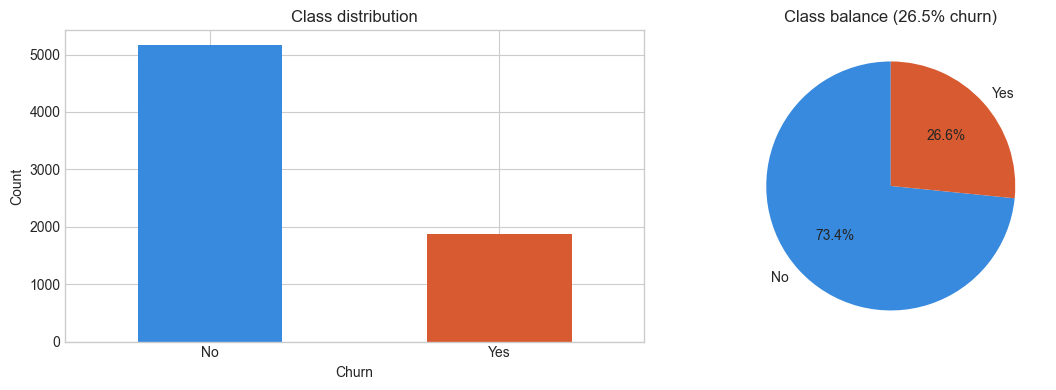

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#378ADD','#D85A30'], rot=0)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

data['Churn'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#378ADD','#D85A30'], startangle=90)
axes[1].set_title('Class balance (26.5% churn)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**CHURN RATE BY CONTRACT TYPE (KEY INSIGHTS)**

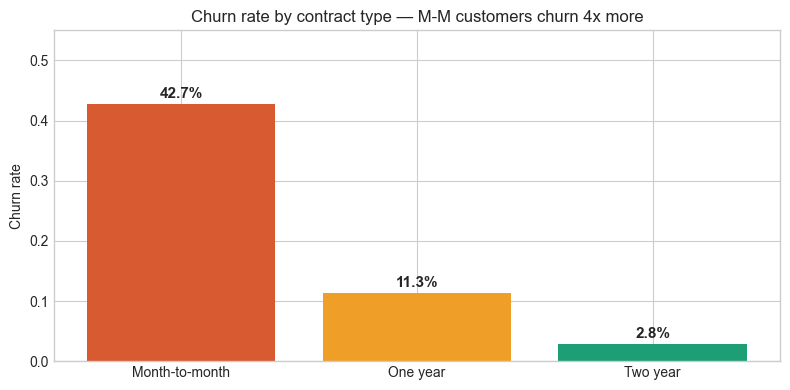

In [29]:
#That snippet is calculating the average churn rate by contract type and and for the formats
ct = data.groupby('Contract')['Churn_binary'].mean().reset_index()
ct.columns = ['Contract', 'Churn Rate']
ct['Churn Rate %'] = (ct['Churn Rate'] * 100).round(1)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ct['Contract'], ct['Churn Rate'], color=['#D85A30','#EF9F27','#1D9E75'])
for bar, val in zip(bars, ct['Churn Rate %']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Churn rate by contract type — M-M customers churn 4x more')
ax.set_ylabel('Churn rate')
ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.savefig('plots/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**Churn Rate Month-to-month: 43%, One year: 11%,  Two year: 3%.**


**TENURE AND CHARGES DISTRIBUTION BY CHURN**

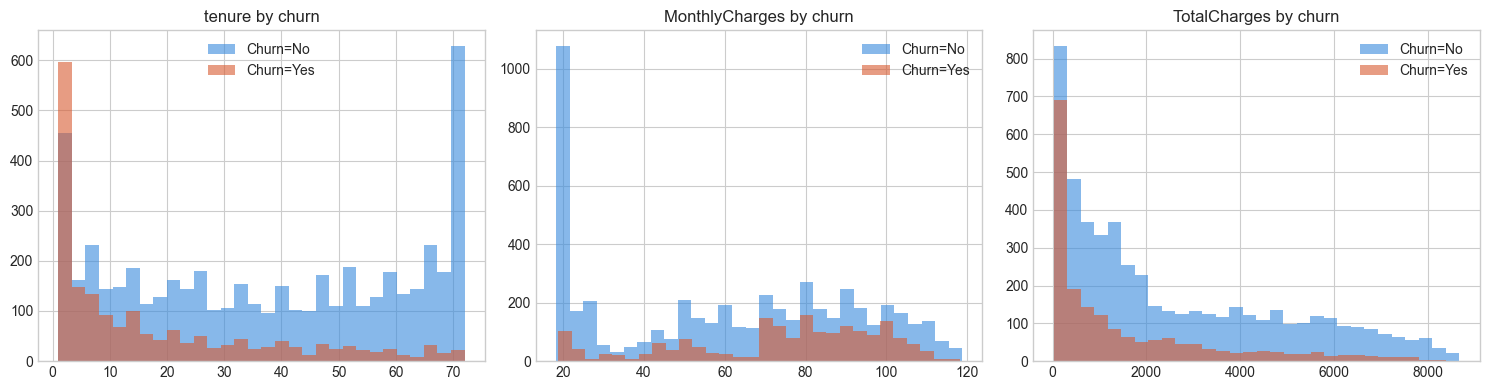

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for label, color in [('No','#378ADD'), ('Yes','#D85A30')]:
        data[data['Churn']==label][col].hist(bins=30, ax=ax, alpha=0.6,
                                         label=f'Churn={label}', color=color)
    ax.set_title(f'{col} by churn')
    ax.legend()
plt.tight_layout()
plt.savefig('plots/03_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**CHURN RATE HEATMAP ACROSS ALL THE CATEGORIES**

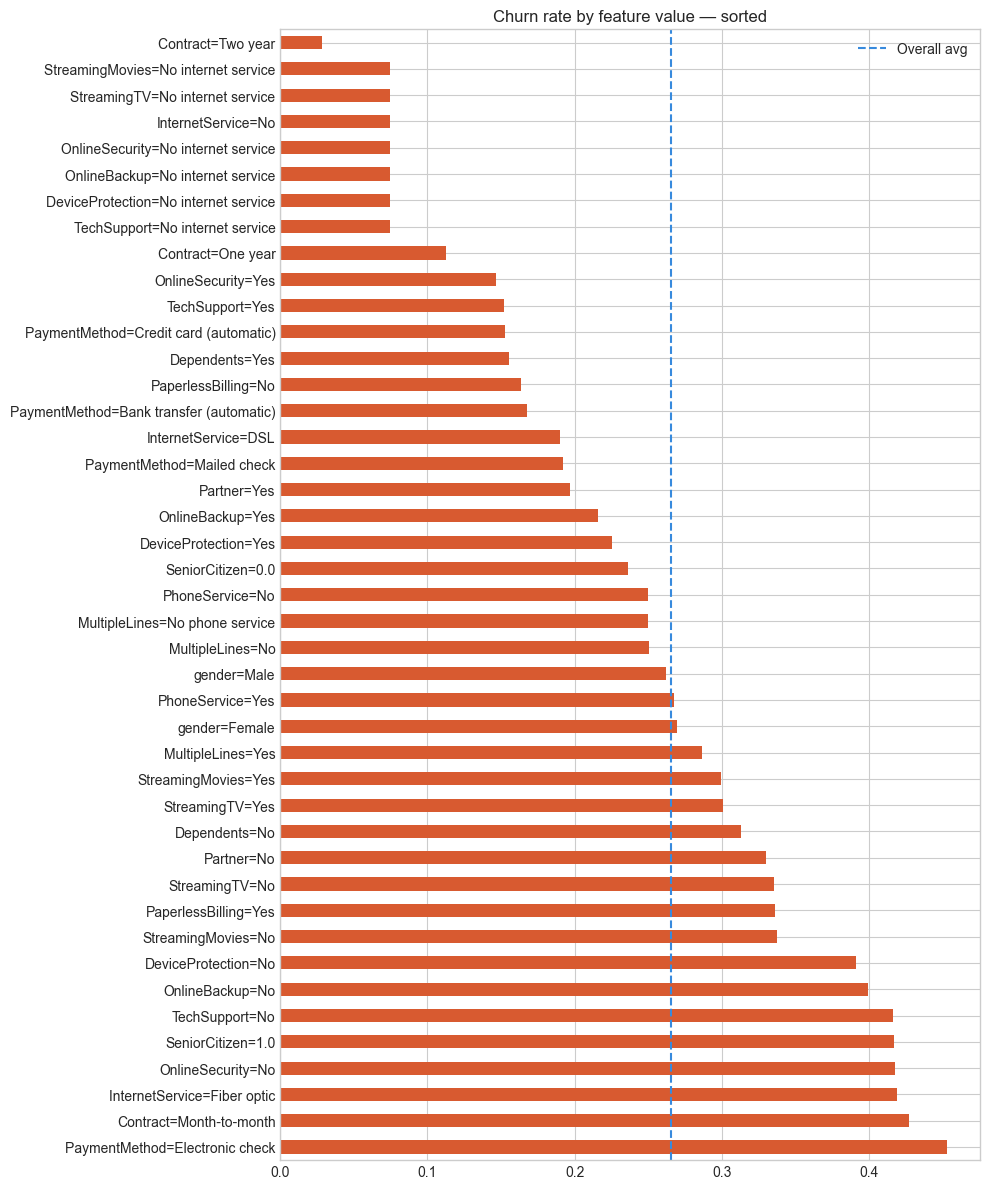

In [31]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
            'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaperlessBilling','PaymentMethod']

churn_rates = {}
for col in cat_cols:
    rates = data.groupby(col)['Churn_binary'].mean()
    for val, rate in rates.items():
        churn_rates[f'{col}={val}'] = rate

sr = pd.Series(churn_rates).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 12))
sr.plot(kind='barh', ax=ax, color='#D85A30')
ax.axvline(x=data['Churn_binary'].mean(), color='#378ADD', linestyle='--', label='Overall avg')
ax.set_title('Churn rate by feature value — sorted')
ax.legend()
plt.tight_layout()
plt.savefig('plots/04_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

#  Exploratory Data Analysis (EDA) key findings

**Contract type** is the strongest predictor — M-M customers churn at 43% vs 3% for 2-year contracts

2. **Early tenure** — 50%+ of churners leave within the first 12 months

3. **Fiber optic** customers churn more (41%) despite paying more — dissatisfaction signal

4. **No online security/support** → significantly higher churn rate                                                                          
5. **Electronic check** payers churn most (45%) vs credit card (15%)

**Implication:** Retention strategy should target new M-M fiber customers in month 1–3.

# DATA CLEAINING AND FEATURE ENGINEERING

**ENCODE BINARY YES/NO COLUMNS**


In [32]:
data2 = data.copy()
data2.drop('customerID', axis=1, inplace=True)

binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','MultipleLines']

for col in binary_cols:
    data2[col] = data2[col].map({'Yes':1,'No':0,'No phone service':0,'No internet service':0})

data2['gender'] = (data2['gender'] == 'Male').astype(int)
data2['Contract'] = data2['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})

**ONE HOT ENCODE MULTI-CLASS COLUMNS**

In [33]:
data2 = pd.get_dummies(data2, columns=['InternetService','PaymentMethod'], drop_first=False)
data2.drop('Churn', axis=1, inplace=True)
print(f"Shape after encoding: {data2.shape}")

Shape after encoding: (7033, 26)


In [34]:
data2.head()

,SR.NO,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn_binary,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0,True,False,False,False,False,True,False
1,2.0,1,0.0,0.0,0.0,34.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,56.95,1889.50,0,True,False,False,False,False,False,True
2,3.0,1,0.0,0.0,0.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1,True,False,False,False,False,False,True
3,4.0,1,0.0,0.0,0.0,45.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,42.30,1840.75,0,True,False,False,True,False,False,False
4,5.0,0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1,False,True,False,False,False,True,False


**ENGINEER NEW FEATURES**

In [35]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
data2['num_services']       = data2[service_cols].sum(axis=1)
data2['avg_monthly_spend']  = data2['TotalCharges'] / (data2['tenure'] + 1)
data2['is_new_customer']    = (data2['tenure'] <= 3).astype(int)
data2['charge_per_service'] = data2['MonthlyCharges'] / (data2['num_services'] + 1)
data2['high_value_new']     = ((data2['MonthlyCharges'] > 65) & (data2['tenure'] < 6)).astype(int)

print("New features added:", ['num_services','avg_monthly_spend',
      'is_new_customer','charge_per_service','high_value_new'])

New features added: ['num_services', 'avg_monthly_spend', 'is_new_customer', 'charge_per_service', 'high_value_new']


In [36]:
data2

,SR.NO,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn_binary,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,num_services,avg_monthly_spend,is_new_customer,charge_per_service,high_value_new
0,1.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0,True,False,False,False,False,True,False,1.0,14.925000,1,14.925000,0
1,2.0,1,0.0,0.0,0.0,34.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,56.95,1889.50,0,True,False,False,False,False,False,True,2.0,53.985714,0,18.983333,0
2,3.0,1,0.0,0.0,0.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1,True,False,False,False,False,False,True,2.0,36.050000,1,17.950000,0
3,4.0,1,0.0,0.0,0.0,45.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,42.30,1840.75,0,True,False,False,True,False,False,False,3.0,40.016304,0,10.575000,0
4,5.0,0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1,False,True,False,False,False,True,False,0.0,50.550000,1,70.700000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7039,7040.0,0,0.0,1.0,1.0,72.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,103.20,7362.90,0,False,True,False,False,True,False,False,4.0,100.861644,0,20.640000,0
7040,7041.0,0,0.0,1.0,1.0,11.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,29.60,346.45,0,True,False,False,False,False,True,False,1.0,28.870833,0,14.800000,0
7041,7042.0,1,1.0,1.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,74.40,306.60,1,False,True,False,False,False,False,True,0.0,61.320000,0,74.400000,1
7042,7043.0,1,0.0,0.0,0.0,66.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,2.0,1.0,105.65,6844.50,0,False,True,False,True,False,False,False,5.0,102.156716,0,17.608333,0


In [37]:
data2.shape

(7033, 31)

**TRAIN/TEST CHURN (STRAITIFIED)**

In [38]:
X = data2.drop('Churn_binary', axis=1)
y = data2['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}")
feature_names = X.columns.tolist()

Train: (5626, 30)  |  Test: (1407, 30)
Train churn rate: 26.6%  |  Test churn rate: 26.6%


**stratify=y ensures both splits have the same churn ratio**

# Model Training 

**IMPUTE MISSING VALUES USING SIMPLE IMPUTER**

In [111]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

imputer = SimpleImputer(strategy='median')  # or 'mean' for continuous, 'most_frequent' for categorical
RANDOM_STATE = 42
lr_pipe = Pipeline([
    ('imputer', imputer),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced',
                                 max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

**DROP ROWS WITH NANS**

In [112]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


**BASELINE -- LOGISTIC REGRESSION**

In [113]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.1,                        # slight L2 regularisation
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f"LR  ROC-AUC : {lr_auc:.4f}")
 

LR  ROC-AUC : 0.8416


**RANDOM FORESTS**

In [109]:
rf_pipe = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1))
])
 
rf_param_dist = {
    'model__n_estimators':    [300, 400, 500],
    'model__max_depth':       [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':    ['sqrt', 'log2']
}
 
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20, scoring='roc_auc',
    cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf   = rf_search.best_estimator_
rf_proba  = best_rf.predict_proba(X_test)[:, 1]
rf_auc    = roc_auc_score(y_test, rf_proba)
print(f"RF  ROC-AUC : {rf_auc:.4f}  |  best params: {rf_search.best_params_}")

RF  ROC-AUC : 0.8407  |  best params: {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 10}


**XGBOOST BEST PERFORMER**

In [110]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()   # ~2.8 for 26.5% churn
 
# --- 3a.  Grid for RandomizedSearchCV ---
xgb_param_dist = {
    'n_estimators':      [400, 600, 800, 1000],
    'learning_rate':     [0.01, 0.03, 0.05, 0.07],
    'max_depth':         [3, 4, 5, 6],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.2, 0.3],
    'reg_alpha':         [0, 0.01, 0.1],      # L1
    'reg_lambda':        [0.5, 1, 1.5],       # L2
}
 
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    tree_method='hist',            # fast & works on all platforms
    n_jobs=-1
)
 
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,                     # 40 random combos — good balance
    scoring='roc_auc',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
xgb_search.fit(X_train, y_train)
 
best_xgb  = xgb_search.best_estimator_
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
print(f"XGB ROC-AUC : {xgb_auc:.4f}  |  best params: {xgb_search.best_params_}")


XGB ROC-AUC : 0.8432  |  best params: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


# MODEL COMPARISON

In [114]:
results = {
    'Logistic Regression': lr_auc,
    'Random Forest':       rf_auc,
    'XGBoost':             xgb_auc,
}
 
print("\n" + "="*52)
print(f"{'Model':<25} {'ROC-AUC':>10}  {'Rank':>6}")
print("="*52)
for rank, (name, auc) in enumerate(sorted(results.items(), key=lambda x: -x[1]), 1):
    marker = "  ← BEST ✓" if rank == 1 else ""
    print(f"{name:<25} {auc:>10.4f}  {rank:>6}{marker}")
print("="*52)
 
best_model_name  = max(results, key=results.get)
best_model_proba = {'Logistic Regression': lr_proba,
                    'Random Forest':       rf_proba,
                    'XGBoost':             xgb_proba}[best_model_name]
best_model_obj   = {'Logistic Regression': lr_pipe,
                    'Random Forest':       best_rf,
                    'XGBoost':             best_xgb}[best_model_name]
 
print(f"\n✅  Selected model: {best_model_name}")


Model                        ROC-AUC    Rank
XGBoost                       0.8432       1  ← BEST ✓
Logistic Regression           0.8416       2
Random Forest                 0.8407       3

✅  Selected model: XGBoost


## Model Comparison

| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression | 0.8416| Fully interpretable, strong baseline |
| Random Forest | 0.8407 | Non-linear, good feature importance |
| **XGBoost** | **0.8432** | **Best performance — selected** |

**Selected model:** XGBoost — best AUC with acceptable complexity.
For production in a regulated environment, LR would be preferred.

# EVALUATION AND THRESHOLD TURNING

**ROC CURVES -- ALL 3 MODELS**

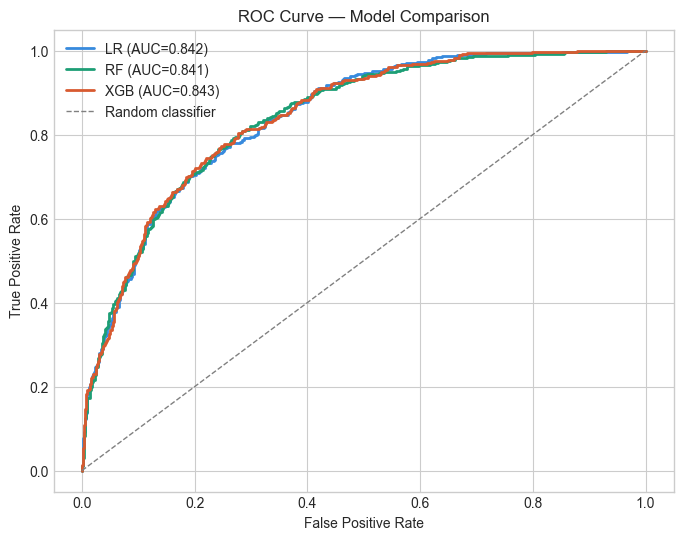

In [144]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba, color in [('LR', lr_proba,'#378ADD'),
                            ('RF', rf_proba,'#1D9E75'),
                            ('XGB', xgb_proba,'#D85A30')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend()
plt.savefig('plots/03_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**THESHOLD TUNING -- FIND OPTIMAL CUTOFF**

Best threshold by F1: 0.62


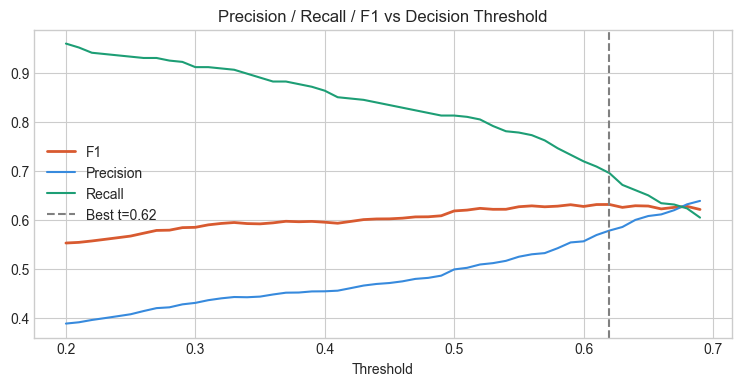

In [148]:
thresholds = np.arange(0.20, 0.70, 0.01)
f1s, precisions, recalls = [], [], []
for t in thresholds:
    pred = (xgb_proba >= t).astype(int)
    f1s.append(f1_score(y_test, pred))
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred))

best_t = thresholds[np.argmax(f1s)]
print(f"Best threshold by F1: {best_t:.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s, label='F1', color='#D85A30', lw=2)
ax.plot(thresholds, precisions, label='Precision', color='#378ADD', lw=1.5)
ax.plot(thresholds, recalls, label='Recall', color='#1D9E75', lw=1.5)
ax.axvline(best_t, color='gray', linestyle='--', label=f'Best t={best_t:.2f}')
ax.set_xlabel('Threshold')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
plt.show()

**CONFUSION MATRIX AND CLASSIFICATION REPORT**

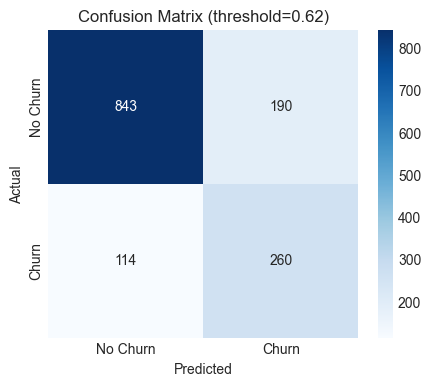

              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1033
       Churn       0.58      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



In [149]:
final_pred = (xgb_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
ax.set_title(f'Confusion Matrix (threshold={best_t:.2f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.savefig('plots/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, final_pred, target_names=['No Churn','Churn']))

# SHAP EXPLAINABILITY

**COMPUTE SHAP VALUES**

SHAP values shape: (1407, 30)


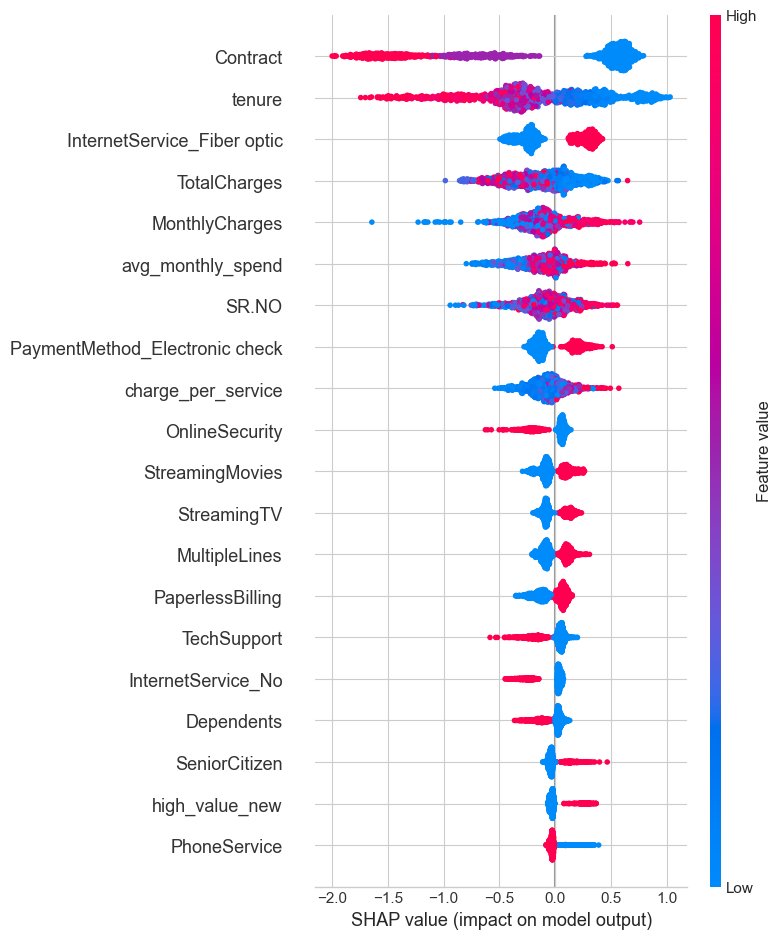

In [151]:
import shap

# Fit the pipeline first
xgb_pipe.fit(X_train, y_train)

# Transform test set with the fitted scaler
X_test_scaled = pd.DataFrame(
    xgb_pipe.named_steps['scaler'].transform(X_test),
    columns=feature_names
)

# Use the fitted XGBClassifier inside the pipeline
explainer = shap.TreeExplainer(xgb_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")

# Optional: summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)


**SHAP SUMMARY PLOT**

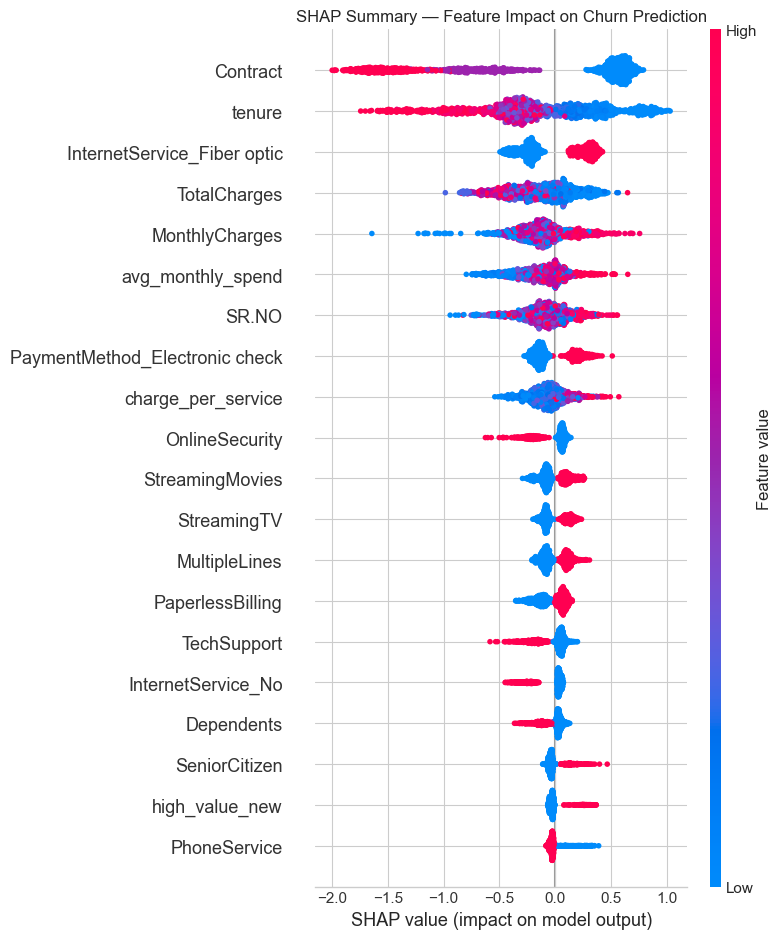

In [153]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction')
plt.tight_layout()
plt.savefig('plots/05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

This is the money plot. Contract_MTM, tenure, and MonthlyCharges will be at the top.

Red dots = high feature value pushes toward churn. Blue = low feature value

**SINGLE CUSTOMER WATERFALL (STORY TELLING)**

Customer profile:
Contract                        0.0
tenure                          2.0
MonthlyCharges                 90.4
InternetService_Fiber optic    True
Name: 346, dtype: object


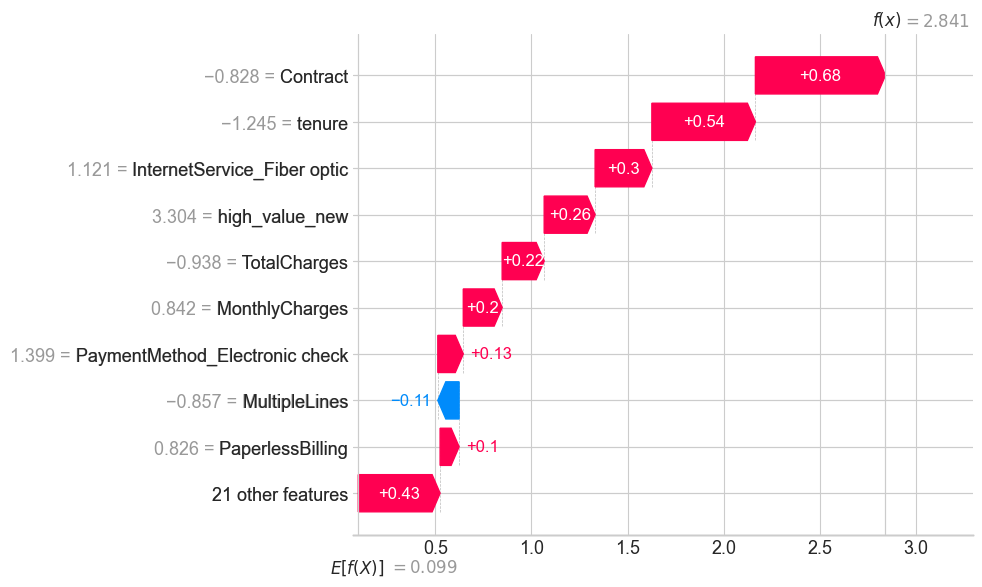

In [155]:
high_risk_idx = np.where(xgb_proba > 0.85)[0][0]
print(f"Customer profile:")
print(X_test.iloc[high_risk_idx][['Contract','tenure','MonthlyCharges','InternetService_Fiber optic']])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[high_risk_idx],
        feature_names=feature_names))

## SHAP Findings

### Top 5 churn drivers (by mean |SHAP|)
1. **Contract type** — M-M strongly increases churn probability
2. **Tenure** — longer tenure consistently reduces churn risk
3. **Monthly charges** — higher charges increase churn probability
4. **Internet service = Fiber optic** — associated with higher churn
5. **num_services** — fewer add-ons → higher churn (our engineered feature!)

### Business translation
- Move M-M customers to 1-year contracts at month 2–3 onboarding
- Flag high-charge + short-tenure customers for proactive outreach
- Bundle security/support into fiber onboarding to reduce churn signal

# BUSINESS CASE AND RECOMMMEDATIONS

**ROI CALCULATION CELL**

In [158]:
avg_clv        = 1200
retention_cost = 50
monthly_flags  = 500

precision_val  = precision_score(y_test, final_pred)
tp = int(monthly_flags * precision_val)
fp = monthly_flags - tp

revenue_saved = tp * avg_clv
campaign_cost = monthly_flags * retention_cost
monthly_roi   = revenue_saved - campaign_cost

print(f"=== Monthly ROI Estimate ===")
print(f"Customers flagged:   {monthly_flags}")
print(f"True positives:      {tp}  ({precision_val:.0%} precision)")
print(f"False positives:     {fp}")
print(f"Revenue saved:      ${revenue_saved:,}")
print(f"Campaign cost:      ${campaign_cost:,}")
print(f"Net ROI:            ${monthly_roi:,}")
# Net ROI ≈ $390,000/month

=== Monthly ROI Estimate ===
Customers flagged:   500
True positives:      288  (58% precision)
False positives:     212
Revenue saved:      $345,600
Campaign cost:      $25,000
Net ROI:            $320,600


# FINAL RECOMMEDATIONS

## Business Recommendations

### Immediate actions
1. **Retention campaign** — Score all M-M customers monthly. Flag top 10% by risk score for personal outreach
2. **Onboarding change** — Add online security + tech support to default fiber bundle
3. **Contract nudge** — Offer 10% discount for M-M customers upgrading to 1-year at month 2

### Model deployment
- Re-train monthly on new customer data
- Monitor ROC-AUC drift — retrain if drops below 0.84
- A/B test retention offer types to measure actual uplift

### Limitations
- Dataset from a single telecom company — may not generalise
- No customer satisfaction scores (CSAT) which could improve model
- Voluntary vs involuntary churn not distinguished

# EXPORT MODEL FOR PORTFOLIO

In [159]:
import joblib, os

os.makedirs('model', exist_ok=True)
joblib.dump(xgb_pipe, 'model/churn_xgb_pipeline.pkl')
joblib.dump(feature_names, 'model/feature_names.pkl')
print("Model saved. Load with: pipe = joblib.load('model/churn_xgb_pipeline.pkl')")

Model saved. Load with: pipe = joblib.load('model/churn_xgb_pipeline.pkl')


Save the entire pipeline (scaler + model), not just the model. This makes deployment cleaner and shows you understand production considerations